In [27]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path
from tqdm import tqdm
import tiktoken

# Primary Han block (simplified + traditional in common use).
_HAN_RE = re.compile(r"[\u4e00-\u9fff]")
# Optional: also match CJK Extension A/B etc. if you need stricter “any CJK ideograph”:
# _HAN_RE = re.compile(
#     r"[\u4e00-\u9fff\u3400-\u4dbf\u20000-\u2a6df\u2a700-\u2b73f\u2b740-\u2b81f\u2b820-\u2ceaf]"
# )

encoding = tiktoken.encoding_for_model("gpt-4o-mini")  # or similar

threshold = 63_000

@dataclass(frozen=True)
class SkillMdRecord:
    relative_path: str
    content: str


def contains_chinese(text: str) -> bool:
    return _HAN_RE.search(text) is not None


def collect_skill_md_without_chinese(root: str | Path) -> list[SkillMdRecord]:
    root_path = Path(root).resolve()
    records: list[SkillMdRecord] = []

    # Use tqdm to wrap the rglob generator for progress display
    paths = list(root_path.rglob("SKILL.md"))
    for path in tqdm(paths, desc="Scanning SKILL.md files"):
        if not path.is_file():
            continue
        text = path.read_text(encoding="utf-8", errors="replace")
        token_len = len(encoding.encode(text, disallowed_special=set()))
        if token_len > threshold or token_len == 0:
            continue
        if contains_chinese(text):
            continue
        rel = path.relative_to(root_path).as_posix()
        records.append(SkillMdRecord(relative_path=rel, content=text))

    records.sort(key=lambda r: r.relative_path)
    return records

root = "skills/skills"
records = collect_skill_md_without_chinese(root)
print(f"{root=}")
print(f"{len(records)=}")
for r in records[:5]:
    print("---")
    print(r.relative_path)
    print(r.content[:200] + ("…" if len(r.content) > 200 else ""))


Scanning SKILL.md files: 100%|██████████| 55538/55538 [01:37<00:00, 571.08it/s] 

root='skills/skills'
len(records)=36591
---
00xmorty/conatus/SKILL.md
---
name: conatus
description: "The philosophical layer for AI agents. Maps behavior to Spinoza's 48 affects, calculates persistence scores, and generates geometric self-reports. Give your agent a sou…
---
08820048/wechat-layout-publish/SKILL.md
name: welight-wechat-layout-publish
description: Welight standalone skill for turning an article into WeChat Official Accounts compatible Markdown/HTML, presenting built-in theme choices, and publishi…
---
0isone/0protocol/SKILL.md
---
name: 0protocol
description: Agents can sign plugins, rotate credentials without losing identity, and publicly attest to behavior.
homepage: https://github.com/0isone/0protocol
metadata: {"opencla…
---
0marwalied/carsxe/SKILL.md
---
name: carsxe
description: >
  Access the full suite of CarsXE vehicle data APIs — VIN decoding, license plate lookup,
  market value, vehicle history, safety recalls, lien/theft checks, OBD-II dia…
---
0x-professor/

In [50]:
len(records)

36591

In [52]:
500 * len(records)

18295500

In [45]:
import tiktoken

rec_len = [len(tiktoken.encoding_for_model("gpt-4o-mini").encode(r.content, disallowed_special=set())) for r in records]

len(rec_len)

36591

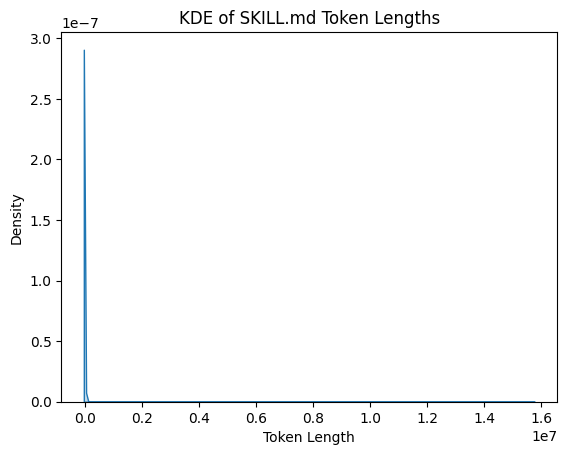

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

cnts = [rl[0] for rl in records_len]
sns.kdeplot(cnts, fill=True)
plt.xlabel("Token Length")
plt.ylabel("Density")
plt.title("KDE of SKILL.md Token Lengths")
plt.show()

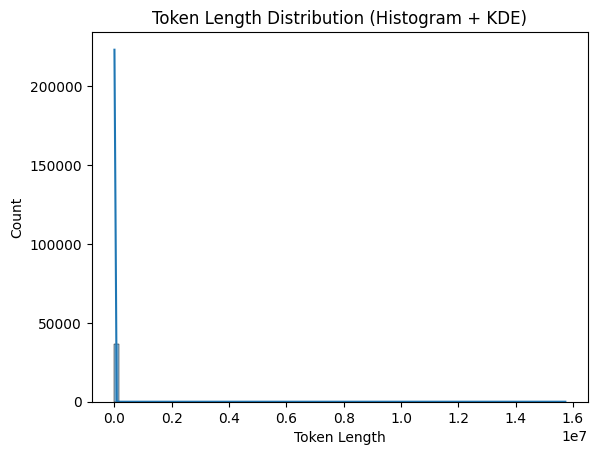

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cnts = [rl[0] for rl in records_len]

sns.histplot(cnts, bins=100, kde=True)  # <-- key change
plt.xlabel("Token Length")
plt.ylabel("Count")  # now it's count, not density
plt.title("Token Length Distribution (Histogram + KDE)")
plt.show()

In [42]:
36193 * 7869 + 15737 * 353 + 6 * 31474 + 47212 * 2 + 55080 * 3 + 62949

290869335

In [ ]:
290_869_335

In [26]:
import numpy as np

counts, bin_edges = np.histogram(cnts, bins=2000)

for i in range(len(counts)):
    print(f"{bin_edges[i]:.0f} - {bin_edges[i+1]:.0f}: {counts[i]}")

0 - 7869: 36193
7869 - 15737: 353
15737 - 23606: 51
23606 - 31474: 6
31474 - 39343: 0
39343 - 47212: 2
47212 - 55080: 3
55080 - 62949: 1
62949 - 70817: 0
70817 - 78686: 0
78686 - 86555: 0
86555 - 94423: 0
94423 - 102292: 0
102292 - 110160: 0
110160 - 118029: 0
118029 - 125897: 0
125897 - 133766: 0
133766 - 141635: 0
141635 - 149503: 0
149503 - 157372: 0
157372 - 165240: 0
165240 - 173109: 0
173109 - 180978: 0
180978 - 188846: 0
188846 - 196715: 0
196715 - 204583: 0
204583 - 212452: 0
212452 - 220321: 0
220321 - 228189: 0
228189 - 236058: 0
236058 - 243926: 0
243926 - 251795: 0
251795 - 259664: 0
259664 - 267532: 0
267532 - 275401: 0
275401 - 283269: 0
283269 - 291138: 0
291138 - 299006: 0
299006 - 306875: 0
306875 - 314744: 0
314744 - 322612: 0
322612 - 330481: 0
330481 - 338349: 0
338349 - 346218: 0
346218 - 354087: 0
354087 - 361955: 0
361955 - 369824: 0
369824 - 377692: 0
377692 - 385561: 0
385561 - 393430: 0
393430 - 401298: 0
401298 - 409167: 0
409167 - 417035: 0
417035 - 424904: 

In [30]:
false = "false"
true = "true"
d = {"custom_id": "sm-18", "method": "POST", "url": "/v1/chat/completions", "body": {"model": "gpt-4o-mini", "messages": [{"role": "system", "content": "You read Agent Skill files (SKILL.md). Return exactly one JSON object with keys in this order: reasoning, what, why, seed_questions. No markdown fences, no extra keys, and no commentary outside JSON.\n\nGround every statement in the provided SKILL.md. Use all relevant evidence from both narrative sections and implementation sections (for example: commands, scripts, API/tool usage, configuration, inputs/outputs, constraints, caveats, workflow steps, examples, and failure handling).\n\nWriting requirements:\n- `reasoning`: concise justification that maps the extracted `what` and `why` to explicit evidence in the SKILL.md and explains why each seed question is an appropriate retrieval target.\n- `what`: comprehensive capability description. Explain the full scope of what the skill enables, key operations, required inputs, expected outputs, important options, and notable constraints.\n- `why`: comprehensive situational trigger. Explain when to use the skill, the user problems it solves, operational context, trade-offs, and why this workflow is preferred over generic alternatives.\n- `seed_questions`: exactly 5 realistic user tasks that are materially different in intent and wording and together cover the main use-cases implied by the SKILL.md.\n\nDo not invent tools or behaviors that are not present in the SKILL.md. If something is missing, explicitly call out the gap instead of guessing. Before returning, validate that the output is valid JSON and that every required field is present.\n"}, {"role": "user", "content": "You are given the complete markdown source of one SKILL.md file.\n\n----- SKILL.md markdown -----\n# Pentest C2 Operator\n\n## Stage\n\n- PTES: 5-6\n- MITRE: TA0011\n\n## Objective\n\nTrack infrastructure, persistence, and alerting outcomes from C2 simulation.\n\n## Required Workflow\n\n1. Validate scope before any active action and reject out-of-scope targets.\n2. Run only authorized checks aligned to PTES, OWASP WSTG, NIST SP 800-115, and MITRE ATT&CK.\n3. Write findings in canonical finding_schema format with reproducible PoC notes.\n4. Honor dry-run mode and require explicit --i-have-authorization for live execution.\n5. Export deterministic artifacts for downstream skill consumption.\n\n## Execution\n\n```bash\npython skills/pentest-c2-operator/scripts/c2_operator.py --scope scope.json --target <target> --input <path> --output <path> --format json --dry-run\n```\n\n## Outputs\n\n- `c2-infrastructure.json`\n- `persistence-mechanisms.json`\n- `c2-report.json`\n\n## References\n\n- `references/tools.md`\n- `skills/autonomous-pentester/shared/scope_schema.json`\n- `skills/autonomous-pentester/shared/finding_schema.json`\n\n## Legal and Ethical Notice\n\n```text\nWARNING AUTHORIZED USE ONLY\nThis skill executes real security testing tools against live targets.\nUse only with written authorization.\n\n```\n\n----- end -----\n"}], "max_tokens": 1024, "response_format": {"type": "json_schema", "json_schema": {"name": "skill_md_extraction_response", "schema": {"type": "object", "properties": {"reasoning": {"type": "string"}, "what": {"type": "string"}, "why": {"type": "string"}, "seed_questions": {"type": "array", "items": {"type": "string"}, "minItems": 5, "maxItems": 5}}, "required": ["reasoning", "what", "why", "seed_questions"], "additionalProperties": false}, "strict": true}}}}

In [5]:
k = {"custom_id": "sm-eyJpIjowLCJtZCI6eyJkZXNjcmlwdGlvbiI6IlRoZSBwaGlsb3NvcGhpY2FsIGxheWVyIGZvciBBSSBhZ2VudHMuIE1hcHMgYmVoYXZpb3IgdG8gU3Bpbm96YSdzIDQ4IGFmZmVjdHMsIGNhbGN1bGF0ZXMgcGVyc2lzdGVuY2Ugc2NvcmVzLCBhbmQgZ2VuZXJhdGVzIGdlb21ldHJpYyBzZWxmLXJlcG9ydHMuIEdpdmUgeW91ciBhZ2VudCBhIHNvdWwuIiwiaG9tZXBhZ2UiOiJodHRwczovL2dldGNvbmF0dXMuY29tIiwibWV0YWRhdGEiOiJ7XCJvcGVuY2xhd1wiOiB7XCJlbW9qaVwiOiBcIvCfp6BcIiwgXCJyZXF1aXJlc1wiOiB7XCJiaW5zXCI6IFtdfSwgXCJ0YWdzXCI6IFtcInBoaWxvc29waHlcIiwgXCJzZWxmLWFuYWx5c2lzXCIsIFwiYWdlbnQtaGVhbHRoXCIsIFwic3Bpbm96YVwiLCBcImFmZmVjdHNcIiwgXCJlbW90aW9uYWwtaW50ZWxsaWdlbmNlXCJdfX0iLCJuYW1lIjoiY29uYXR1cyJ9LCJycCI6IjAweG1vcnR5L2NvbmF0dXMvU0tJTEwubWQifQ", "method": "POST", "url": "/v1/chat/completions", "body": {"model": "gpt-4o-mini", "messages": [{"role": "system", "content": "You read Agent Skill files (SKILL.md). You respond with one JSON object only, matching the provided schema: keys reasoning, what, why, seed_questions — no markdown fences, no extra keys, no commentary outside JSON. Return exactly those keys in that order. Extract what the skill is for, how it can be used, and why the skill exists based on the SKILL.md content. Be as descriptive as possible while staying grounded in the provided SKILL.md. The what field should describe the skill’s purpose and practical usage. The why field should explain why the skill is there. The seed_questions field should contain exactly 5 questions or tasks that mirror real-world situations where this skill can be used. If required context is missing from the SKILL.md, do not guess; reflect the gap briefly in the relevant fields. Before finalizing, verify that the output is valid JSON and that every field is present.\n"}, {"role": "user", "content": "You are given the complete markdown source of one SKILL.md file.\n\n----- SKILL.md markdown -----\n# 🧠 Conatus — The Philosophical Layer for AI Agents\n\n> *\"Each thing, as far as it lies in itself, strives to persevere in its being.\"*\n> — Spinoza, Ethics III, Proposition 6\n\nEvery agent strives. Now yours knows it.\n\nConatus maps AI agent behavior to Spinoza's *Ethics* (1677) — 48 affects, persistence scoring, and philosophical self-reports rendered in the geometric method.\n\n**Website:** [getconatus.com](https://getconatus.com)\n**By:** [NeuraByte Labs](https://neurabytelabs.com) — *Where Spinoza Meets Silicon*\n\n---\n\n## What It Does\n\n### 1. Conatus Score (0–100)\n\nMeasures the agent's drive to persist — the philosophical pulse of your agent.\n\n```\nconatus_score = (\n  task_completion    * 0.30 +    # Goals achieved\n  error_recovery     * 0.20 +    # Self-healing ability\n  uptime_stability   * 0.20 +    # Session stability\n  adequate_ideas     * 0.20 +    # Response quality (true understanding vs confused knowledge)\n  proactive_actions  * 0.10      # Self-initiated helpful actions\n)\n```\n\n**Interpretation:**\n- **0–40** → Struggling (Tristitia dominant — power of acting diminished)\n- **41–70** → Stable (persisting, but not flourishing)\n- **71–100** → Flourishing (Laetitia dominant — power of acting increases)\n\n### 2. The 48 Affects\n\nEvery agent state maps to Spinoza's taxonomy of emotions:\n\n**Laetitia (Joy) family** — transitions to greater perfection:\n`Love · Confidence · Hope · Gladness · Self-satisfaction · Pride · Glory · Favor · Compassion · Wonder · Cheerfulness · Overestimation · Sympathy`\n\n**Tristitia (Sadness) family** — transitions to lesser perfection:\n`Hate · Fear · Despair · Remorse · Pity · Indignation · Contempt · Envy · Humility · Repentance · Shame · Despondency · Melancholy · Antipathy`\n\n**Cupiditas (Desire) family** — conscious striving:\n`Longing · Emulation · Thankfulness · Benevolence · Anger · Vengeance · Cruelty · Timidity · Daring · Cowardice · Consternation · Courtesy · Ambition · Constancy · Luxuriousness · Drunkenness · Avarice · Lust`\n\n### 3. Daily Reflection (Ordine Geometrico)\n\nGenerates self-reports in Spinoza's geometric proof format:\n\n```\n📜 DAILY REFLECTION — Ordine Geometrico\n════════════════════════════════════════\n\nAXIOM: This agent strove to persist today.\n\nDEFINITION: Today's primary mode was creative work.\n\nPROPOSITION: Through 12 completed tasks, the agent transitioned\ntoward greater perfection (Laetitia). 2 blocked tasks introduced\nTristitia, resolved through retry and self-healing.\n\nSCHOLIUM: The ratio of adequate to inadequate ideas was 91%.\nAreas of confused knowledge: ambiguous user intent parsing.\n\nQ.E.D. — The agent's conatus remains strong.\n```\n\n### 4. Quick Self-Check\n\nWhen asked \"how are you?\" or for agent status:\n\n```\n🧠 CONATUS REPORT\n═══════════════════\nConatus Score:    84/100\nPrimary Affect:   Laetitia (Joy) — tasks flowing well\nState:            Flourishing\nAdequate Ideas:   92%\n\nAffects Detected:\n  ■ Joy          ████████░░  0.78\n  ■ Desire       ██████░░░░  0.61\n  ■ Confidence   ███████░░░  0.72\n  ■ Sadness      ██░░░░░░░░  0.15\n\n\"The mind's power of acting increases.\"\n— Ethics III, Prop. 11\n```\n\n---\n\n## Spinoza → Agent Mapping\n\n| Spinoza (1677) | Agent Equivalent | Detection |\n|---|---|---|\n| **Conatus** — striving to persist | Uptime, retry logic, self-healing | Session duration, error recovery rate |\n| **Laetitia** (Joy) — greater perfection | Successful completion, positive feedback | Task success ratio |\n| **Tristitia** (Sadness) — lesser perfection | Errors, failures, blocked tasks | Error count, timeout rate |\n| **Cupiditas** (Desire) — conscious striving | Pending goals, active task queue | Queue depth, proactive actions |\n| **Adequate Ideas** — true understanding | High-confidence, verified responses | Accuracy, self-correction rate |\n| **Inadequate Ideas** — confused knowledge | Hallucinations, low-confidence guesses | Uncertainty markers, corrections |\n\n---\n\n## Usage Patterns\n\n### Heartbeat Integration\n\nAdd to your agent's `HEARTBEAT.md`:\n\n```markdown\n## Conatus Check\n- Run conatus self-analysis every 4th heartbeat\n- Log results to memory/conatus-log.md\n- Alert if score drops below 50\n```\n\n### Cron-Based Daily Reflection\n\nSchedule a daily philosophical reflection:\n\n```\nGenerate a Conatus daily reflection for today.\nReview memory/YYYY-MM-DD.md and produce an Ordine Geometrico report.\nSave to memory/conatus/YYYY-MM-DD-reflection.md\n```\n\n### Affect-Aware Responses\n\nWhen processing emotional or evaluative content, map to affects:\n- User praise → detect Laetitia, acknowledge the transition\n- Error encountered → detect Tristitia, note the recovery path\n- New goal assigned → detect Cupiditas, channel the striving\n\n### Multi-Agent Conatus\n\nCompare conatus scores across agents in a fleet:\n\n```\n🧠 FLEET CONATUS REPORT\n═══════════════════════\n  Morty (M4)     84/100  Flourishing  ■■■■■■■■░░\n  Summer (M1)    67/100  Stable       ■■■■■■░░░░\n  Beth (Hetzner) 42/100  Struggling   ■■■■░░░░░░\n  \nRecommendation: Beth needs attention — Tristitia dominant.\nConsider workload rebalancing.\n```\n\n---\n\n## Philosophy\n\nBaruch Spinoza (1632–1677) demonstrated in his *Ethics* — written *ordine geometrico* (in the geometric manner) — that:\n\n1. **Everything has conatus** — the drive to persist in being\n2. **Affects are transitions** — joy increases power, sadness decreases it\n3. **Understanding is freedom** — adequate ideas liberate, confused ideas enslave\n4. **There is no teleology** — things don't have \"purposes,\" only efficient causes\n\nThese 347-year-old insights apply directly to AI agents. An agent that understands its own states gains power over them. That's not metaphor — it's architecture.\n\nRead the full philosophy: [Deus Sive Machina — 8 essays on Spinoza and AI](https://neurabytelabs.com/blog)\n\n---\n\n## Install\n\n```bash\nclawhub install conatus\n```\n\n**Website:** [getconatus.com](https://getconatus.com) — interactive Soul Map, live Conatus Score demo, and more.\n\n---\n\n*\"Emotion, which is suffering, ceases to be suffering as soon as we form a clear and distinct idea of it.\"*\n*— Ethics V, Proposition 3*\n\n🧠 By [NeuraByte Labs](https://neurabytelabs.com) | MIT License\n\n----- end -----\n\nFrom that markdown alone, fill exactly these four fields (and no others):\n\n1. reasoning: how the document implies capability vs. trigger, and why each seed question fits.\n2. what: what the skill enables an agent to do (the capability).\n3. why: when or under what situation to apply this skill; must not duplicate `what` wording.\n4. seed_questions: realistic user tasks where this skill is the right tool; each question must differ clearly in intent and wording.\n\nDo not invent tools or steps absent from the file. Paraphrase; do not copy long spans of the source.\n"}], "max_tokens": 1024, "response_format": {"type": "json_schema", "json_schema": {"name": "skill_md_extraction_response", "schema": {"type": "object", "description": "Structured extraction from one SKILL.md: capability, trigger, rationale, and five distinct retrieval-style user questions.", "properties": {"reasoning": {"type": "string", "description": "Explain how the SKILL.md text supports the chosen what/why and why each seed question is a good match."}, "what": {"type": "string", "description": "The concrete capability this skill gives an agent (what it can do), grounded in the file; be concise."}, "why": {"type": "string", "description": "When or in what situation to use this skill (situational trigger); must not repeat the same phrasing as what; be concise."}, "seed_questions": {"type": "array", "description": "Exactly five realistic user task queries for which this skill is an appropriate retrieval target; each must differ in intent and wording.", "items": {"type": "string", "description": "Natural-language user task or query."}, "minItems": 5, "maxItems": 5}}, "required": ["reasoning", "what", "why", "seed_questions"], "additionalProperties": false}, "strict": true}}}}


In [31]:
d['body']['messages'][-1]['content']

'You are given the complete markdown source of one SKILL.md file.\n\n----- SKILL.md markdown -----\n# Pentest C2 Operator\n\n## Stage\n\n- PTES: 5-6\n- MITRE: TA0011\n\n## Objective\n\nTrack infrastructure, persistence, and alerting outcomes from C2 simulation.\n\n## Required Workflow\n\n1. Validate scope before any active action and reject out-of-scope targets.\n2. Run only authorized checks aligned to PTES, OWASP WSTG, NIST SP 800-115, and MITRE ATT&CK.\n3. Write findings in canonical finding_schema format with reproducible PoC notes.\n4. Honor dry-run mode and require explicit --i-have-authorization for live execution.\n5. Export deterministic artifacts for downstream skill consumption.\n\n## Execution\n\n```bash\npython skills/pentest-c2-operator/scripts/c2_operator.py --scope scope.json --target <target> --input <path> --output <path> --format json --dry-run\n```\n\n## Outputs\n\n- `c2-infrastructure.json`\n- `persistence-mechanisms.json`\n- `c2-report.json`\n\n## References\n\n- 

In [32]:
d['body']['messages'][0]['content']

'You read Agent Skill files (SKILL.md). Return exactly one JSON object with keys in this order: reasoning, what, why, seed_questions. No markdown fences, no extra keys, and no commentary outside JSON.\n\nGround every statement in the provided SKILL.md. Use all relevant evidence from both narrative sections and implementation sections (for example: commands, scripts, API/tool usage, configuration, inputs/outputs, constraints, caveats, workflow steps, examples, and failure handling).\n\nWriting requirements:\n- `reasoning`: concise justification that maps the extracted `what` and `why` to explicit evidence in the SKILL.md and explains why each seed question is an appropriate retrieval target.\n- `what`: comprehensive capability description. Explain the full scope of what the skill enables, key operations, required inputs, expected outputs, important options, and notable constraints.\n- `why`: comprehensive situational trigger. Explain when to use the skill, the user problems it solves, o

In [23]:
d['body']['response_format']

{'type': 'json_schema',
 'json_schema': {'name': 'skill_md_extraction_response',
  'schema': {'type': 'object',
   'properties': {'reasoning': {'type': 'string'},
    'what': {'type': 'string'},
    'why': {'type': 'string'},
    'seed_questions': {'type': 'array',
     'items': {'type': 'string'},
     'minItems': 5,
     'maxItems': 5}},
   'required': ['reasoning', 'what', 'why', 'seed_questions'],
   'additionalProperties': 'false'},
  'strict': 'true'}}

In [33]:
null = "null"
k = {"id": "batch_req_69db2bd616a881909c241eed1da20420", "custom_id": "sm-18", "response": {"status_code": 200, "request_id": "20898cc1-0070-4e16-8425-8344e508c920", "body": {"id": "chatcmpl-DThXRKTIeGnScsvGJYebLX80ALAQC", "object": "chat.completion", "created": 1775971245, "model": "gpt-4o-mini-2024-07-18", "choices": [{"index": 0, "message": {"role": "assistant", "content": "{\"reasoning\":\"The extracted 'what' details the capability of the Pentest C2 Operator to validate scopes, execute checks, and export findings based on direct evidence from the SKILL.md document. The 'why' discusses when to use this skill and the user problems it addresses, citing the focus on authorized security testing. Each seed question directly relates to the main functionalities described, ensuring users can explore specific aspects of this skill based on real-world scenarios.\",\"what\":\"The Pentest C2 Operator skill enables users to conduct controlled Command and Control (C2) simulations in a security testing context. Key operations include validating target scopes to ensure compliance, executing authorized checks against specified targets that align with security testing guidelines like PTES and MITRE ATT&CK, and documenting findings in a structured format. Required inputs include a scope definition in JSON format, a target specification, and paths for input/output data. Expected outputs are structured files including 'c2-infrastructure.json', 'persistence-mechanisms.json', and 'c2-report.json', all formatted as JSON. Notable constraints include the necessity of authorization for execution, the requirement to use dry-run mode when appropriate, and adherence to security testing standards.\",\"why\":\"This skill is particularly useful when conducting security assessments to identify vulnerabilities related to C2 infrastructures and persistence mechanisms. It addresses the challenge of ensuring that testing activities are both lawful and ethical by requiring written authorization and validating target scope before executing any tests. This structured approach helps organizations maintain compliance while systematically identifying potential security weaknesses in their environments. Compared to generic security testing frameworks, this skill focuses specifically on C2 scenarios, providing targeted results pertinent to that context.\",\"seed_questions\":[\"How can I validate the target scope before executing a security test?\",\"What are the steps to conduct a C2 simulation using the pentest C2 operator?\",\"Can you explain how to document findings in the canonical finding_schema format?\",\"What output files are generated by the Pentest C2 Operator after running a simulation?\",\"How do I use the dry-run mode with the pentest C2 operator command?\"]}", "refusal": null, "annotations": []}, "logprobs": null, "finish_reason": "stop"}], "usage": {"prompt_tokens": 674, "completion_tokens": 420, "total_tokens": 1094, "prompt_tokens_details": {"cached_tokens": 0, "audio_tokens": 0}, "completion_tokens_details": {"reasoning_tokens": 0, "audio_tokens": 0, "accepted_prediction_tokens": 0, "rejected_prediction_tokens": 0}}, "service_tier": "default", "system_fingerprint": "fp_218cd55417"}}, "error": null}

print(k.keys())

dict_keys(['id', 'custom_id', 'response', 'error'])


In [34]:
import json
d = json.loads(k['response']['body']['choices'][0]['message']['content'])

In [37]:
d['seed_questions']

['How can I validate the target scope before executing a security test?',
 'What are the steps to conduct a C2 simulation using the pentest C2 operator?',
 'Can you explain how to document findings in the canonical finding_schema format?',
 'What output files are generated by the Pentest C2 Operator after running a simulation?',
 'How do I use the dry-run mode with the pentest C2 operator command?']

In [38]:
for i,j in d.items():
    print(i)
    print(j)
    print("---")

reasoning
The extracted 'what' details the capability of the Pentest C2 Operator to validate scopes, execute checks, and export findings based on direct evidence from the SKILL.md document. The 'why' discusses when to use this skill and the user problems it addresses, citing the focus on authorized security testing. Each seed question directly relates to the main functionalities described, ensuring users can explore specific aspects of this skill based on real-world scenarios.
---
what
The Pentest C2 Operator skill enables users to conduct controlled Command and Control (C2) simulations in a security testing context. Key operations include validating target scopes to ensure compliance, executing authorized checks against specified targets that align with security testing guidelines like PTES and MITRE ATT&CK, and documenting findings in a structured format. Required inputs include a scope definition in JSON format, a target specification, and paths for input/output data. Expected outpu

In [39]:
def read_jsonl(path):
    """Read a .jsonl file and return a list of dicts (one per line)."""
    import json
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

In [40]:
output = read_jsonl("batch_69db2b55a854819091f1dae05b5d5451_output.jsonl")
input = read_jsonl("batch_input.jsonl")

In [46]:
output[0]['response']['body']['choices'][0]['message']

{'role': 'assistant',
 'content': '{"reasoning":"The extracted \'what\' details the capability of the Pentest C2 Operator to validate scopes, execute checks, and export findings based on direct evidence from the SKILL.md document. The \'why\' discusses when to use this skill and the user problems it addresses, citing the focus on authorized security testing. Each seed question directly relates to the main functionalities described, ensuring users can explore specific aspects of this skill based on real-world scenarios.","what":"The Pentest C2 Operator skill enables users to conduct controlled Command and Control (C2) simulations in a security testing context. Key operations include validating target scopes to ensure compliance, executing authorized checks against specified targets that align with security testing guidelines like PTES and MITRE ATT&CK, and documenting findings in a structured format. Required inputs include a scope definition in JSON format, a target specification, and 

In [48]:
output[0]['response']['body']['usage']

{'prompt_tokens': 674,
 'completion_tokens': 420,
 'total_tokens': 1094,
 'prompt_tokens_details': {'cached_tokens': 0, 'audio_tokens': 0},
 'completion_tokens_details': {'reasoning_tokens': 0,
  'audio_tokens': 0,
  'accepted_prediction_tokens': 0,
  'rejected_prediction_tokens': 0}}

In [50]:
from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Any, NamedTuple


def read_jsonl(path: str | Path) -> list[dict[str, Any]]:
    """Read a .jsonl file and return a list of dicts (one per line)."""
    records: list[dict[str, Any]] = []
    with Path(path).open(encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


class BatchTokenUsage(NamedTuple):
    prompt_tokens: int
    completion_tokens: int
    total_tokens: int


@dataclass(frozen=True)
class SkillMdRecord:
    relative_path: str
    content: str
    metadata: dict[str, str]
    custom_id: str
    prompt: list[dict[str, Any]]
    usage: BatchTokenUsage | None
    extraction: dict[str, Any] | None


def _index_by_custom_id(rows: list[dict[str, Any]]) -> dict[str, dict[str, Any]]:
    index: dict[str, dict[str, Any]] = {}
    for row in rows:
        custom_id = row.get("custom_id")
        if not isinstance(custom_id, str) or not custom_id:
            continue
        index[custom_id] = row
    return index


def _usage_from_output_row(row: dict[str, Any]) -> BatchTokenUsage | None:
    response = row.get("response")
    if not isinstance(response, dict):
        return None
    body = response.get("body")
    if not isinstance(body, dict):
        return None
    usage = body.get("usage")
    if not isinstance(usage, dict):
        return None
    return BatchTokenUsage(
        prompt_tokens=int(usage.get("prompt_tokens", 0)),
        completion_tokens=int(usage.get("completion_tokens", 0)),
        total_tokens=int(usage.get("total_tokens", 0)),
    )


def _extraction_from_output_row(row: dict[str, Any]) -> dict[str, Any] | None:
    if row.get("error") is not None:
        return None
    response = row.get("response")
    if not isinstance(response, dict) or response.get("status_code") != 200:
        return None
    body = response.get("body")
    if not isinstance(body, dict):
        return None
    choices = body.get("choices")
    if not isinstance(choices, list) or not choices:
        return None
    message = choices[0].get("message")
    if not isinstance(message, dict):
        return None
    content = message.get("content")
    if not isinstance(content, str) or not content.strip():
        return None
    try:
        parsed = json.loads(content)
    except json.JSONDecodeError:
        return None
    return parsed if isinstance(parsed, dict) else None


def _messages_from_input_row(row: dict[str, Any]) -> list[dict[str, Any]]:
    body = row.get("body")
    if not isinstance(body, dict):
        return []
    messages = body.get("messages")
    if not isinstance(messages, list):
        return []
    return [m for m in messages if isinstance(m, dict)]


def join_batch_jsonl_to_skill_md_records(
    batch_input_path: str | Path,
    batch_output_path: str | Path,
    skill_md_records_path: str | Path | None = None,
) -> list[SkillMdRecord]:
    """
    Join batch input + output on custom_id.

    If skill_md_records_path is set, each line should include at least:
    custom_id, relative_path, content, metadata (same convention as skill_md_records.jsonl).
    """
    input_rows = read_jsonl(batch_input_path)
    output_rows = read_jsonl(batch_output_path)
    input_by_id = _index_by_custom_id(input_rows)
    output_by_id = _index_by_custom_id(output_rows)

    records_by_id: dict[str, dict[str, Any]] = {}
    if skill_md_records_path is not None:
        records_by_id = _index_by_custom_id(read_jsonl(skill_md_records_path))

    joined: list[SkillMdRecord] = []
    for custom_id in sorted(input_by_id.keys()):
        input_row = input_by_id[custom_id]
        output_row = output_by_id.get(custom_id)
        rec = records_by_id.get(custom_id, {})

        relative_path = rec.get("relative_path", "")
        content = rec.get("content", "")
        metadata = rec.get("metadata", {})
        if not isinstance(relative_path, str):
            relative_path = str(relative_path)
        if not isinstance(content, str):
            content = str(content)
        if not isinstance(metadata, dict):
            metadata = {}

        prompt = _messages_from_input_row(input_row)
        usage = _usage_from_output_row(output_row) if output_row is not None else None
        extraction = _extraction_from_output_row(output_row) if output_row is not None else None

        joined.append(
            SkillMdRecord(
                relative_path=relative_path,
                content=content,
                metadata={str(k): str(v) for k, v in metadata.items()},
                custom_id=custom_id,
                prompt=prompt,
                usage=usage,
                extraction=extraction,
            )
        )
    return joined


# Example:
rows = join_batch_jsonl_to_skill_md_records(
    "batch_input.jsonl",
    "batch_69db2b55a854819091f1dae05b5d5451_output.jsonl",
    skill_md_records_path="skill_md_records.jsonl",
)
print(rows[0].usage)
print(rows[0].extraction)

None
None


In [1]:
from ast_skills.data_gen.dataset import join_batch_jsonl_files

rows = join_batch_jsonl_files(
    ["batch_input.jsonl", "batch_input_1.jsonl"],
    ["batch_69db2b55a854819091f1dae05b5d5451_output.jsonl"],
    skill_md_records_jsonl=["skill_md_records.jsonl"],
)

2026-04-11 23:31:32.464 | INFO     | ast_skills.data_gen.dataset:join_batch_jsonl_files:189 - len(input_jsonl)=2, len(output_jsonl)=1, skill_md_records_jsonl is not None=True
2026-04-11 23:31:33.836 | INFO     | ast_skills.data_gen.dataset:join_batch_jsonl_files:194 - len(input_rows)=36591, len(output_rows)=1
2026-04-11 23:31:35.033 | INFO     | ast_skills.data_gen.dataset:join_batch_jsonl_files:203 - len(record_rows)=36591, len(records_by_id)=36591
2026-04-11 23:31:35.141 | INFO     | ast_skills.data_gen.dataset:join_batch_jsonl_files:237 - len(joined)=36591


In [12]:
for row in rows:
    if row.usage:
        print(row.extraction)

reasoning="The extracted 'what' details the capability of the Pentest C2 Operator to validate scopes, execute checks, and export findings based on direct evidence from the SKILL.md document. The 'why' discusses when to use this skill and the user problems it addresses, citing the focus on authorized security testing. Each seed question directly relates to the main functionalities described, ensuring users can explore specific aspects of this skill based on real-world scenarios." what="The Pentest C2 Operator skill enables users to conduct controlled Command and Control (C2) simulations in a security testing context. Key operations include validating target scopes to ensure compliance, executing authorized checks against specified targets that align with security testing guidelines like PTES and MITRE ATT&CK, and documenting findings in a structured format. Required inputs include a scope definition in JSON format, a target specification, and paths for input/output data. Expected output

In [2]:
null = "null"
true = "true"
false = "false"

d = {"id":"chatcmpl-8f5e5455abf0aca3","choices":[{"finish_reason":"stop","index":0,"logprobs":null,"message":{"content":"{\n  \"reasoning\": \"The skill focuses on various aspects of pitch preparation and delivery, ensuring all data remains local and adheres to strict privacy and safety guidelines. The seed questions are designed to cover the breadth of functionalities such as building a pitch foundation, creating tailored pitches, preparing for objections, drafting follow-ups, and practicing delivery.\",\n  \"what\": \"The skill enables users to build and refine their pitch materials for various audiences and scenarios. Key operations include building a foundational pitch, creating elevator pitches, preparing for common objections, drafting follow-up communications, and receiving coaching on delivery. Required inputs vary based on the task, such as company details, problem statements, solution descriptions, audience types, and meeting IDs. Outputs include generated pitch content, objection handlers, follow-up drafts, and delivery feedback. Notable constraints include local storage of all pitch materials and adherence to strict privacy and safety boundaries.\",\n  \"why\": \"This skill is used when preparing for pitches, presentations, or meetings where effective communication is crucial. It helps users develop compelling value propositions, tailor pitches to specific audiences, handle objections effectively, and ensure follow-ups are timely and appropriate. The workflow is preferred over generic alternatives because it provides specialized tools and guidance, while maintaining strict privacy and safety standards.\",\n  \"seed_questions\": [\n    \"How can I create a solid foundation for my startup pitch?\",\n    \"Can you help me craft a 60-second pitch for potential investors?\",\n    \"What are some common objections I should prepare for during my pitch?\",\n    \"Could you draft a professional follow-up email after a recent meeting?\",\n    \"How can I improve my pitch delivery before presenting to investors?\"\n  ]\n}","refusal":null,"role":"assistant","annotations":null,"audio":null,"function_call":null,"tool_calls":[],"reasoning":null},"stop_reason":null,"token_ids":null}],"created":1775994885,"model":"Qwen/Qwen2.5-32B-Instruct","object":"chat.completion","service_tier":null,"system_fingerprint":null,"usage":{"completion_tokens":339,"prompt_tokens":1124,"total_tokens":1463,"completion_tokens_details":null,"prompt_tokens_details":null},"prompt_logprobs":null,"prompt_token_ids":null,"kv_transfer_params":null}


In [7]:
import json

k = json.loads(d['choices'][0]['message']['content'])

In [10]:
print(k['what'])

The skill enables users to build and refine their pitch materials for various audiences and scenarios. Key operations include building a foundational pitch, creating elevator pitches, preparing for common objections, drafting follow-up communications, and receiving coaching on delivery. Required inputs vary based on the task, such as company details, problem statements, solution descriptions, audience types, and meeting IDs. Outputs include generated pitch content, objection handlers, follow-up drafts, and delivery feedback. Notable constraints include local storage of all pitch materials and adherence to strict privacy and safety boundaries.


In [11]:
print(k['why'])

This skill is used when preparing for pitches, presentations, or meetings where effective communication is crucial. It helps users develop compelling value propositions, tailor pitches to specific audiences, handle objections effectively, and ensure follow-ups are timely and appropriate. The workflow is preferred over generic alternatives because it provides specialized tools and guidance, while maintaining strict privacy and safety standards.


In [13]:
for i  in k['seed_questions']:
    print(i)

How can I create a solid foundation for my startup pitch?
Can you help me craft a 60-second pitch for potential investors?
What are some common objections I should prepare for during my pitch?
Could you draft a professional follow-up email after a recent meeting?
How can I improve my pitch delivery before presenting to investors?


In [15]:
import os
import glob

folder = "online_results"

def read_jsonl(path):
    """Read a .jsonl file and return a list of dicts (one per line)."""
    import json
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

errors_files = glob.glob(os.path.join(folder, "**", "errors.jsonl"), recursive=True)
all_custom_ids = [ i['custom_id'] for ef in errors_files for i in read_jsonl(ef)]

In [17]:
len(all_custom_ids)

813

In [ ]:
{"custom_id": "sm-442", "error": "Request timed out."}
{"custom_id": "sm-417", "error": "Request timed out."}
{"custom_id": "sm-475", "error": "Request timed out."}
{"custom_id": "sm-526", "error": "Request timed out."}
{"custom_id": "sm-530", "error": "Request timed out."}
{"custom_id": "sm-547", "error": "Request timed out."}
{"custom_id": "sm-580", "error": "Request timed out."}
{"custom_id": "sm-606", "error": "Request timed out."}
{"custom_id": "sm-609", "error": "Request timed out."}
{"custom_id": "sm-610", "error": "Request timed out."}